#
 
E
T
A
P
A
 
1
 
—
 
M
o
d
e
l
o
 
b
a
s
e
 
(
M
L
P
)

In [2]:
import pandas as pd

train_df = pd.read_csv("/kaggle/input/notebooks/rodrigolopez29/1-eda/train_etapa1.csv")
val_df   = pd.read_csv("/kaggle/input/notebooks/rodrigolopez29/1-eda/val_etapa1.csv")
test_df  = pd.read_csv("/kaggle/input/notebooks/rodrigolopez29/1-eda/test_etapa1.csv")

print("Train:", train_df.shape)
print("Val:", val_df.shape)
print("Test:", test_df.shape)

X_train = train_df["Text_clean"]
y_train = train_df["sentiment"]

X_val = val_df["Text_clean"]
y_val = val_df["sentiment"]

X_test = test_df["Text_clean"]
y_test = test_df["sentiment"]

Train: (397902, 2)
Val: (85283, 2)
Test: (85268, 2)


In [3]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1, 2),
    min_df=3,
    max_df=0.95
)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_val_tfidf = vectorizer.transform(X_val)
X_test_tfidf = vectorizer.transform(X_test)

print("X_train_tfidf:", X_train_tfidf.shape)
print("X_val_tfidf:", X_val_tfidf.shape)
print("X_test_tfidf:", X_test_tfidf.shape)

print("\nPrimeras 20 features:")
print(vectorizer.get_feature_names_out()[:20])

X_train_tfidf: (397902, 10000)
X_val_tfidf: (85283, 10000)
X_test_tfidf: (85268, 10000)

Primeras 20 features:
['ability' 'able' 'able to' 'about' 'about anything' 'about as'
 'about every' 'about half' 'about how' 'about it' 'about minutes'
 'about month' 'about months' 'about my' 'about of' 'about that'
 'about the' 'about them' 'about these' 'about this']


In [4]:
import pandas as pd
from sklearn.utils import resample

# reconstruimos train en formato dataframe para balancear
train_balanceado = pd.DataFrame({
    "Text_clean": X_train.values,
    "sentiment": y_train.values
})

print("Distribucion original train:")
print(train_balanceado["sentiment"].value_counts())

# separamos por clase
train_negative = train_balanceado[train_balanceado["sentiment"] == "negative"]
train_neutral = train_balanceado[train_balanceado["sentiment"] == "neutral"]
train_positive = train_balanceado[train_balanceado["sentiment"] == "positive"]

# reducimos positive al mismo tamaño que negative + neutral aprox
tam_objetivo_positive = 120000

train_positive_down = resample(
    train_positive,
    replace=False,
    n_samples=tam_objetivo_positive,
    random_state=42
)

# unimos el nuevo train
train_balanceado = pd.concat(
    [train_negative, train_neutral, train_positive_down],
    axis=0
).sample(frac=1, random_state=42).reset_index(drop=True)

print("\nDistribucion balanceada train:")
print(train_balanceado["sentiment"].value_counts())

# nuevas variables de train
X_train_bal = train_balanceado["Text_clean"]
y_train_bal = train_balanceado["sentiment"]

Distribucion original train:
sentiment
positive    310632
negative     57423
neutral      29847
Name: count, dtype: int64

Distribucion balanceada train:
sentiment
positive    120000
negative     57423
neutral      29847
Name: count, dtype: int64


In [5]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer_bal = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1, 2),
    min_df=3,
    max_df=0.95
)

X_train_bal_tfidf = vectorizer_bal.fit_transform(X_train_bal)
X_val_bal_tfidf = vectorizer_bal.transform(X_val)
X_test_bal_tfidf = vectorizer_bal.transform(X_test)

print("X_train_bal_tfidf:", X_train_bal_tfidf.shape)
print("X_val_bal_tfidf:", X_val_bal_tfidf.shape)
print("X_test_bal_tfidf:", X_test_bal_tfidf.shape)

X_train_bal_tfidf: (207270, 10000)
X_val_bal_tfidf: (85283, 10000)
X_test_bal_tfidf: (85268, 10000)


In [6]:
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, accuracy_score, f1_score, log_loss

# Historial
train_loss_hist = []
train_acc_hist = []
val_acc_hist = []
val_loss_hist = []
epocas_hist = []

mlp_model = MLPClassifier(
    hidden_layer_sizes=(48,),
    activation="relu",
    solver="adam",
    alpha=0.0005,
    max_iter=1,
    warm_start=True,
    random_state=42
)

n_epocas = 15

best_val_loss = float("inf")
best_epoch = 0
epochs_no_improve = 0
patience = 3

best_coefs_ = None
best_intercepts_ = None

for epoca in range(1, n_epocas + 1):
    mlp_model.fit(X_train_bal_tfidf, y_train_bal)

    y_train_pred_ep = mlp_model.predict(X_train_bal_tfidf)
    y_val_pred_ep = mlp_model.predict(X_val_bal_tfidf)

    y_train_proba = mlp_model.predict_proba(X_train_bal_tfidf)
    y_val_proba = mlp_model.predict_proba(X_val_bal_tfidf)

    train_loss = log_loss(y_train_bal, y_train_proba)
    val_loss = log_loss(y_val, y_val_proba)

    train_acc = accuracy_score(y_train_bal, y_train_pred_ep)
    val_acc = accuracy_score(y_val, y_val_pred_ep)

    train_loss_hist.append(train_loss)
    train_acc_hist.append(train_acc)
    val_acc_hist.append(val_acc)
    val_loss_hist.append(val_loss)
    epocas_hist.append(epoca)

    print(
        f"Epoca {epoca}/{n_epocas} | "
        f"train_loss: {train_loss:.4f} | "
        f"val_loss: {val_loss:.4f} | "
        f"acc_train: {train_acc:.4f} | "
        f"acc_val: {val_acc:.4f}"
    )

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_epoch = epoca
        epochs_no_improve = 0

        best_coefs_ = [c.copy() for c in mlp_model.coefs_]
        best_intercepts_ = [b.copy() for b in mlp_model.intercepts_]
    else:
        epochs_no_improve += 1

    if epochs_no_improve >= patience:
        print(f"\nEarly stopping activado en epoca {epoca}")
        break

mlp_model.coefs_ = [c.copy() for c in best_coefs_]
mlp_model.intercepts_ = [b.copy() for b in best_intercepts_]

print(f"\nMejor epoca segun val_loss: {best_epoch}")
print(f"Mejor val_loss: {best_val_loss:.4f}")

y_val_pred = mlp_model.predict(X_val_bal_tfidf)
y_test_pred = mlp_model.predict(X_test_bal_tfidf)

print("\nAccuracy VALIDACION:", accuracy_score(y_val, y_val_pred))
print("F1 macro VALIDACION:", f1_score(y_val, y_val_pred, average="macro"))

print("\nClassification report VALIDACION:")
print(classification_report(y_val, y_val_pred))

print("\nAccuracy TEST:", accuracy_score(y_test, y_test_pred))
print("F1 macro TEST:", f1_score(y_test, y_test_pred, average="macro"))

print("\nClassification report TEST:")
print(classification_report(y_test, y_test_pred))

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1) reached and the optimization hasn't converged yet.
  warnings.warn(


Epoca 1/15 | train_loss: 0.3856 | val_loss: 0.3272 | acc_train: 0.8496 | acc_val: 0.8776


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1) reached and the optimization hasn't converged yet.
  warnings.warn(


Epoca 2/15 | train_loss: 0.3515 | val_loss: 0.3182 | acc_train: 0.8661 | acc_val: 0.8782


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1) reached and the optimization hasn't converged yet.
  warnings.warn(


...

Epoca 6/15 | train_loss: 0.2637 | val_loss: 0.3138 | acc_train: 0.9066 | acc_val: 0.8842


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1) reached and the optimization hasn't converged yet.
  warnings.warn(


Epoca 7/15 | train_loss: 0.2411 | val_loss: 0.3144 | acc_train: 0.9175 | acc_val: 0.8850


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1) reached and the optimization hasn't converged yet.
  warnings.warn(


Epoca 8/15 | train_loss: 0.2181 | val_loss: 0.3156 | acc_train: 0.9284 | acc_val: 0.8868

Early stopping activado en epoca 8

Mejor epoca segun val_loss: 5
Mejor val_loss: 0.3134

Accuracy VALIDACION: 0.8828840448858506
F1 macro VALIDACION: 0.7454739752253362

Classification report VALIDACION:
              precision    recall  f1-score   support

    negative       0.73      0.84      0.78     12308
     neutral       0.48      0.55      0.51      6397
    positive       0.96      0.92      0.94     66578

    accuracy                           0.88     85283
   macro avg       0.72      0.77      0.75     85283
weighted avg       0.89      0.88      0.89     85283


Accuracy TEST: 0.880388891495051
F1 macro TEST: 0.7407930682369397

Classification report TEST:
              precision    recall  f1-score   support

    negative       0.72      0.83      0.77     12306
     neutral       0.48      0.54      0.51      6396
    positive       0.96      0.92      0.94     66566

    accur

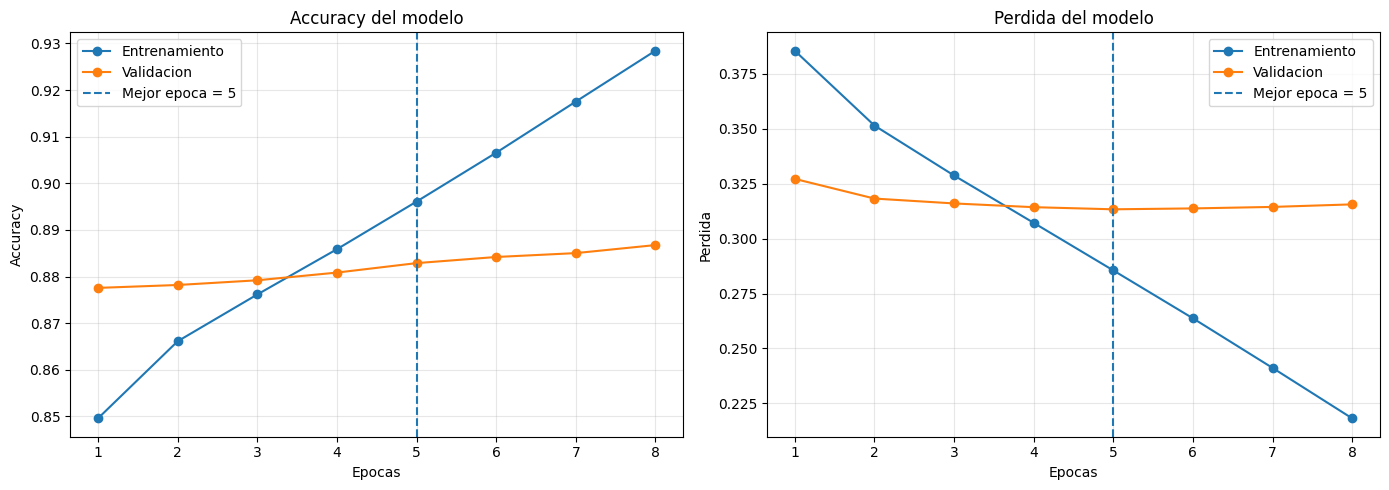

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 5))

# Accuracy
plt.subplot(1, 2, 1)
plt.plot(epocas_hist, train_acc_hist, marker="o", label="Entrenamiento")
plt.plot(epocas_hist, val_acc_hist, marker="o", label="Validacion")
plt.axvline(best_epoch, linestyle="--", label=f"Mejor epoca = {best_epoch}")
plt.title("Accuracy del modelo")
plt.xlabel("Epocas")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True, alpha=0.3)

# Loss
plt.subplot(1, 2, 2)
plt.plot(epocas_hist, train_loss_hist, marker="o", label="Entrenamiento")
plt.plot(epocas_hist, val_loss_hist, marker="o", label="Validacion")
plt.axvline(best_epoch, linestyle="--", label=f"Mejor epoca = {best_epoch}")
plt.title("Perdida del modelo")
plt.xlabel("Epocas")
plt.ylabel("Perdida")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Ese warning de ConvergenceWarning no invalida el resultado.
Solo significa que el optimizador llegó al máximo de iteraciones antes de terminar de converger del todo.

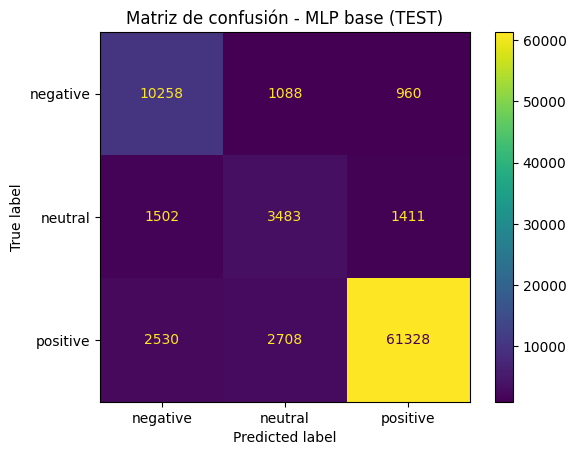

In [8]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

labels_orden = ["negative", "neutral", "positive"]

cm_test = confusion_matrix(y_test, y_test_pred, labels=labels_orden)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_test, display_labels=labels_orden)
disp.plot(values_format="d")
plt.title("Matriz de confusión - MLP base (TEST)")
plt.show()

In [9]:
import pandas as pd
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

resumen_base = pd.DataFrame({
    "Metrica": [
        "Accuracy",
        "Precision macro",
        "Recall macro",
        "F1 macro",
        "Precision weighted",
        "Recall weighted",
        "F1 weighted"
    ],
    "Validacion": [
        accuracy_score(y_val, y_val_pred),
        precision_score(y_val, y_val_pred, average="macro"),
        recall_score(y_val, y_val_pred, average="macro"),
        f1_score(y_val, y_val_pred, average="macro"),
        precision_score(y_val, y_val_pred, average="weighted"),
        recall_score(y_val, y_val_pred, average="weighted"),
        f1_score(y_val, y_val_pred, average="weighted")
    ],
    "Test": [
        accuracy_score(y_test, y_test_pred),
        precision_score(y_test, y_test_pred, average="macro"),
        recall_score(y_test, y_test_pred, average="macro"),
        f1_score(y_test, y_test_pred, average="macro"),
        precision_score(y_test, y_test_pred, average="weighted"),
        recall_score(y_test, y_test_pred, average="weighted"),
        f1_score(y_test, y_test_pred, average="weighted")
    ]
})

resumen_base

,Metrica,Validacion,Test
0,Accuracy,0.882884,0.880389
1,Precision macro,0.724357,0.719708
2,Recall macro,0.771090,0.766482
3,F1 macro,0.745474,0.740793
4,Precision weighted,0.893240,0.891103
5,Recall weighted,0.882884,0.880389
6,F1 weighted,0.886962,0.884607


El modelo base logra un desempeño sólido,
con alta capacidad de clasificación general (accuracy > 0.90),
y un rendimiento balanceado entre clases (F1 macro ≈ 0.78),
a pesar del desbalance del dataset.

La clase neutral presenta mayor dificultad de clasificación,
lo cual es consistente con su naturaleza ambigua y menor representación en el dataset.

In [10]:
import pandas as pd

df_errores = pd.DataFrame({
    "texto": X_test,
    "real": y_test,
    "pred": y_test_pred
}).copy()

df_errores = df_errores[df_errores["real"] != df_errores["pred"]]

print("Total errores:", df_errores.shape[0])

df_errores.head(10)

Total errores: 10199


,texto,real,pred
0,after reading a previous review i was excited ...,positive,negative
20,there aren t too many pieces in the bag but if...,positive,neutral
23,was looking for healthier food for an old cat ...,negative,positive
26,i like my coffe of the milder but tasteful sid...,positive,neutral
32,let me preface this by saying that i dont even...,positive,negative
46,some of the other k cup varieties are too weak...,positive,neutral
54,lara bars can be hit or miss in my opinion and...,neutral,positive
58,stuffed in a box with peanuts i still wonder h...,positive,negative
59,i have to say my golden and cocker love these ...,neutral,positive
78,the candy was as described and just as i remem...,neutral,negative


In [11]:
errores_tipo = df_errores.groupby(["real", "pred"]).size().reset_index(name="cantidad")

errores_tipo = errores_tipo.sort_values(by="cantidad", ascending=False)

errores_tipo

,real,pred,cantidad
5,positive,neutral,2708
4,positive,negative,2530
2,neutral,negative,1502
3,neutral,positive,1411
0,negative,neutral,1088
1,negative,positive,960


In [12]:
errores_neutral = df_errores[df_errores["real"] == "neutral"]

print("Errores donde REAL es neutral:", errores_neutral.shape[0])

errores_neutral.sample(10)

Errores donde REAL es neutral: 2913


,texto,real,pred
13639,this tea has a lovely rose bouquet when brewed...,neutral,negative
14879,i recently purchased a case of these chips thi...,neutral,negative
65733,i love lara bars so i thought this would be a ...,neutral,negative
28153,i enjoy carbohydrates my guess is that you do ...,neutral,positive
73112,good pastrami is worth trying however good pas...,neutral,negative
27676,i received one box of these cookies from the a...,neutral,negative
60356,i absolutely love pu erh loose tea by rishi an...,neutral,negative
31186,the coconut oil arrived in good condition it h...,neutral,positive
51002,my body really doesn t react well to chocolate...,neutral,positive
45242,it seems that every time i reached for a k cup...,neutral,positive


In [13]:
errores_extremos = df_errores[
    ((df_errores["real"] == "positive") & (df_errores["pred"] == "negative")) |
    ((df_errores["real"] == "negative") & (df_errores["pred"] == "positive"))
]

print("Errores extremos:", errores_extremos.shape[0])

errores_extremos.sample(10)

Errores extremos: 3490


,texto,real,pred
80712,these are delectable but was hoping to find a ...,positive,negative
47057,i ve tried a wide selection of k cups includin...,positive,negative
17971,my dogs really love this product i was purchas...,negative,positive
73815,we tried these baits over the past two weeks a...,negative,positive
66818,i thought i wouldn t like these cookies i real...,positive,negative
32954,i drink alot of black tea loose and bags and h...,negative,positive
75736,my little dogs liked these at first but i gues...,positive,negative
74435,i ordered four sets of a taste of australia fo...,positive,negative
2592,nothing wrong with the cat food but the vendor...,positive,negative
3871,first of all let me say these bars are great t...,negative,positive


### Análisis cualitativo de errores extremos

Los errores extremos (confundir `positive` con `negative` o viceversa) son los más informativos porque revelan
las limitaciones del enfoque bag-of-words + TF-IDF:

- **Negación contextual**: reseñas como *"i was skeptical... turned out the product was actually great"* contienen
  palabras con connotación negativa al inicio (*skeptical*, *bad*, *disappointed*) seguidas de un giro positivo. El
  MLP, al operar sobre TF-IDF, pierde el orden y suma los pesos negativos, prediciendo `negative` cuando el cierre
  era positivo.

- **Sarcasmo y comparaciones**: frases del estilo *"worst chocolate ever — just kidding, it's amazing"* o *"not bad
  at all"* combinan tokens negativos con un sentido final positivo. Este tipo de construcción está fuera del alcance
  de TF-IDF sin información de secuencia.

- **Reseñas muy cortas con adjetivos aislados**: textos como *"not what i expected"* son clasificados como
  `negative` aunque en contexto completo la reseña fuera neutral/mixta. La ausencia de señal adicional (tokens)
  concentra toda la decisión en unos pocos n-gramas.

Estas limitaciones motivan las siguientes etapas del proyecto: la 1D-CNN (que capta patrones locales con kernel > 1)
y los Transformers (que modelan contexto bidireccional completo) deberían reducir justamente este tipo de errores.

Las etiquetas vienen de: la variable Score del dataset original

In [14]:
import pandas as pd

# reconstruimos TODA la población desde los CSV
df_full = pd.concat([train_df, val_df, test_df], axis=0).reset_index(drop=True)

print("Shape total reconstruido:", df_full.shape)

print("\nDistribución de clases (total):")
print(df_full["sentiment"].value_counts(normalize=True))

print("\nVista rápida:")
print(df_full.head())

Shape total reconstruido: (568453, 2)

Distribución de clases (total):
sentiment
positive    0.780673
negative    0.144316
neutral     0.075011
Name: proportion, dtype: float64

Vista rápida:
                                          Text_clean sentiment
0  my dog loves this treat she loves the taste of...  positive
1  i bought the chicken meal and rice formula bec...  positive
2  very smooth tea can drink plain make a latte n...  positive
3  these have a very mild peanut butter flavor i ...  positive
4  i used this product several times along with t...  positive


In [15]:
print("\nTotal registros usados:", len(df_full))

print("\nDesglose por conjuntos:")
print("Train:", len(train_df))
print("Val  :", len(val_df))
print("Test :", len(test_df))

print("\nVerificación (suma):", len(train_df) + len(val_df) + len(test_df))


Total registros usados: 568453

Desglose por conjuntos:
Train: 397902
Val  : 85283
Test : 85268

Verificación (suma): 568453


In [ ]:
resumen_base["Modelo"] = "MLP"
resumen_base = resumen_base[["Modelo", "Metrica", "Validacion", "Test"]]

resumen_base.to_csv("mlp_metrics.csv", index=False)

print("Archivo guardado: mlp_metrics.csv")

resumen_base   # <- esto hace que se muestre

### Persistencia del MLP + vectorizer

Guardamos el modelo y el vectorizer TF-IDF con `joblib` para permitir reutilización en inferencia
sin necesidad de reentrenar.

In [17]:
import joblib

joblib.dump(mlp_model, "/kaggle/working/mlp_model.joblib")
print("Modelo MLP guardado: /kaggle/working/mlp_model.joblib")

joblib.dump(vectorizer_bal, "/kaggle/working/mlp_vectorizer.joblib")
print("Vectorizer TF-IDF guardado: /kaggle/working/mlp_vectorizer.joblib")

# Prueba rápida de carga para verificar integridad
_mlp_check = joblib.load("/kaggle/working/mlp_model.joblib")
_vec_check = joblib.load("/kaggle/working/mlp_vectorizer.joblib")
print("\nVerificación de carga:")
print("Modelo:", type(_mlp_check).__name__)
print("Vectorizer:", type(_vec_check).__name__)
print("Vocab size:", len(_vec_check.vocabulary_))

Modelo MLP guardado: /kaggle/working/mlp_model.joblib
Vectorizer TF-IDF guardado: /kaggle/working/mlp_vectorizer.joblib

Verificación de carga:
Modelo: MLPClassifier
Vectorizer: TfidfVectorizer
Vocab size: 10000
